# NLP with Machine Learning Assignments

## 1. Sentiment Analysis

1. Create a new _nlp_machine_learning_ environment
2. Launch Jupyter Notebook
3. Read in the _movie_reviews.csv_ file
4. Apply sentiment analysis to the _movie_info_ column
5. Sort the sentiment scores to return the top 10 and bottom 10 sentiment scores and their corresponding movie titles

----------------------------------------------------------------------

3. Read in the movie_reviews.csv file

In [ ]:
from google.colab import files
movie_upload = files.upload()

Saving movie_reviews.csv to movie_reviews.csv


In [ ]:
import pandas as pd

In [ ]:
df_movie = pd.read_csv("movie_reviews.csv")
df_movie

,movie_title,rating,genre,in_theaters_date,movie_info,directors,director_gender,tomatometer_rating,audience_rating,critics_consensus
0,A Dog's Journey,PG,"Drama, Kids & Family",5/17/19,Bailey (voiced again by Josh Gad) is living th...,Gail Mancuso,female,50,92,A Dog's Journey is as sentimental as one might...
1,A Dog's Way Home,PG,Drama,1/11/19,"Separated from her owner, a dog sets off on an...",Charles Martin Smith,male,60,71,A Dog's Way Home may not quite be a family-fri...
2,A Tuba to Cuba,NR,"Documentary, Musical & Performing Arts",2/15/19,The leader of New Orleans' famed Preservation ...,"Danny Clinch, T.G. Herrington",male,100,82,NaN
3,A Vigilante,R,Drama,3/29/19,"A once abused woman, Sadie (Olivia Wilde), dev...",Sarah Daggar-Nickson,female,92,50,Led by Olivia Wilde's fearless performance and...
4,After,PG-13,"Drama, Romance",4/12/19,Based on Anna Todd's best-selling novel which ...,Jenny Gage,female,17,72,"Tepid and tired, After's fun flourishes are le..."
...,...,...,...,...,...,...,...,...,...,...
161,Velvet Buzzsaw,R,"Comedy, Drama, Mystery & Suspense",2/1/19,Velvet Buzzsaw is a satirical thriller set in ...,Dan Gilroy,male,63,36,If you only watch one art-world satire with ho...
162,What Men Want,R,Comedy,2/8/19,Inspired by the Nancy Meyers hit romantic come...,Adam Shankman,male,44,33,"Admittedly uneven but easy to like, What Men W..."
163,Wild Rose,R,"Comedy, Drama",6/21/19,WILD ROSE tells the complicated story of Rose-...,Tom Harper,male,93,88,"There's no shortage of star-is-born stories, b..."
164,Wine Country,R,Comedy,5/8/19,In honor of Rebecca (Rachel Dratch)'s 50th bir...,Amy Poehler,female,66,30,Wine Country's comedy might not be quite as ro...


4. Apply sentiment analysis to the movie_info column

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.2 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
def get_sentiment(text: 'str'):
  analyzer = SentimentIntensityAnalyzer()
  output = analyzer.polarity_scores(text)
  return output

In [ ]:
get_sentiment(df_movie["movie_info"][0])

{'neg': 0.051, 'neu': 0.694, 'pos': 0.255, 'compound': 0.9837}

In [ ]:
type(get_sentiment(df_movie["movie_info"][0]))

dict

In [ ]:
get_sentiment(df_movie["movie_info"][0]).items()

dict_items([('neg', 0.051), ('neu', 0.694), ('pos', 0.255), ('compound', 0.9837)])

In [ ]:
movie_info_sentiment = df_movie["movie_info"].apply(get_sentiment)
movie_info_sentiment

,movie_info
0,"{'neg': 0.051, 'neu': 0.694, 'pos': 0.255, 'co..."
1,"{'neg': 0.0, 'neu': 0.758, 'pos': 0.242, 'comp..."
2,"{'neg': 0.0, 'neu': 0.779, 'pos': 0.221, 'comp..."
3,"{'neg': 0.256, 'neu': 0.464, 'pos': 0.279, 'co..."
4,"{'neg': 0.017, 'neu': 0.809, 'pos': 0.174, 'co..."
...,...
161,"{'neg': 0.106, 'neu': 0.851, 'pos': 0.043, 'co..."
162,"{'neg': 0.0, 'neu': 0.785, 'pos': 0.215, 'comp..."
163,"{'neg': 0.082, 'neu': 0.918, 'pos': 0.0, 'comp..."
164,"{'neg': 0.087, 'neu': 0.708, 'pos': 0.205, 'co..."


In [ ]:
type(movie_info_sentiment)

pandas.core.series.Series

In [ ]:
movie_info_sentiment[0]

{'neg': 0.051, 'neu': 0.694, 'pos': 0.255, 'compound': 0.9837}

In [ ]:
len(movie_info_sentiment)

166

In [ ]:
movie_info_sentiment.tolist()[:10]

[{'neg': 0.051, 'neu': 0.694, 'pos': 0.255, 'compound': 0.9837},
 {'neg': 0.0, 'neu': 0.758, 'pos': 0.242, 'compound': 0.9237},
 {'neg': 0.0, 'neu': 0.779, 'pos': 0.221, 'compound': 0.936},
 {'neg': 0.256, 'neu': 0.464, 'pos': 0.279, 'compound': -0.0334},
 {'neg': 0.017, 'neu': 0.809, 'pos': 0.174, 'compound': 0.9349},
 {'neg': 0.191, 'neu': 0.602, 'pos': 0.207, 'compound': -0.6249},
 {'neg': 0.071, 'neu': 0.799, 'pos': 0.13, 'compound': 0.9035},
 {'neg': 0.398, 'neu': 0.563, 'pos': 0.039, 'compound': -0.9955},
 {'neg': 0.087, 'neu': 0.768, 'pos': 0.146, 'compound': 0.6124},
 {'neg': 0.063, 'neu': 0.802, 'pos': 0.135, 'compound': 0.5267}]

In [ ]:
sentiment_df = pd.DataFrame(movie_info_sentiment.tolist())
sentiment_df

,neg,neu,pos,compound
0,0.051,0.694,0.255,0.9837
1,0.000,0.758,0.242,0.9237
2,0.000,0.779,0.221,0.9360
3,0.256,0.464,0.279,-0.0334
4,0.017,0.809,0.174,0.9349
...,...,...,...,...
161,0.106,0.851,0.043,-0.2732
162,0.000,0.785,0.215,0.9158
163,0.082,0.918,0.000,-0.5106
164,0.087,0.708,0.205,0.9081


In [ ]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

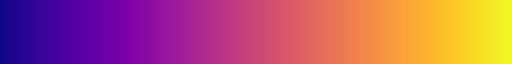

In [ ]:
plt.get_cmap("plasma")

In [ ]:
import seaborn as sns
sns.set()

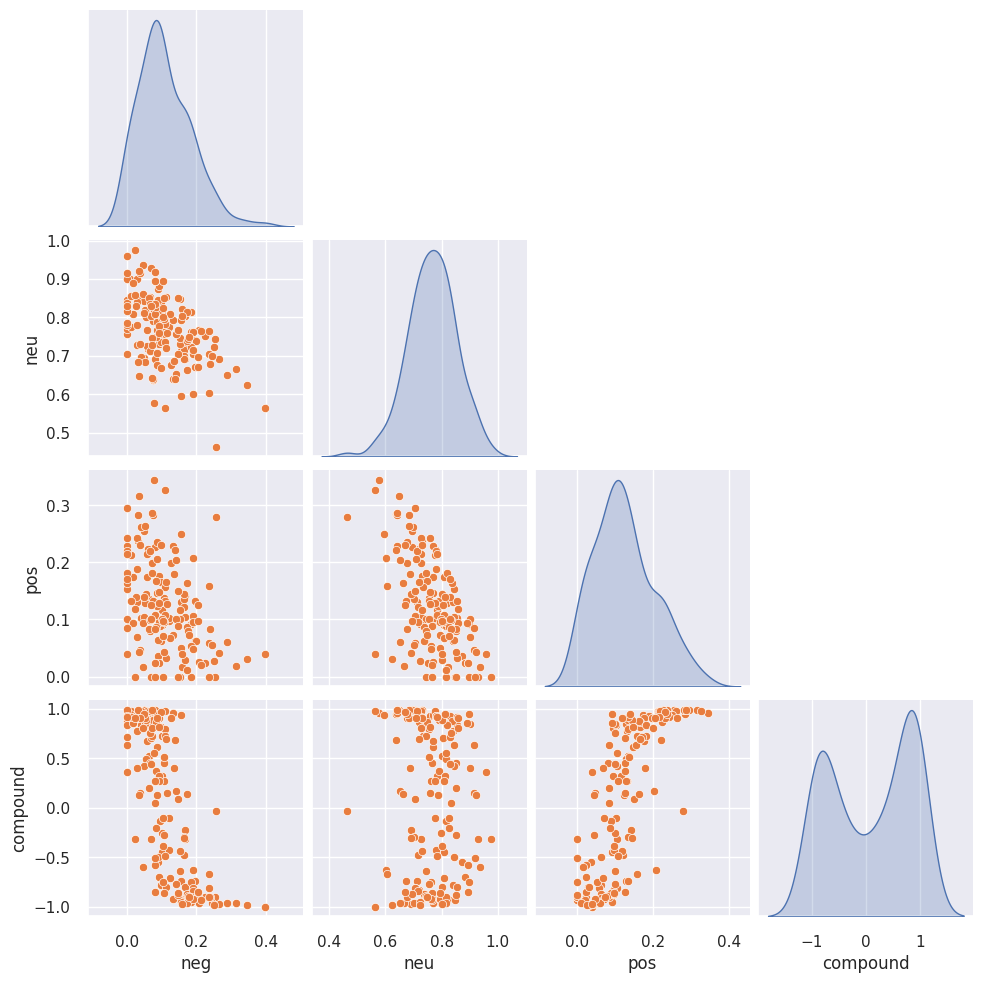

In [ ]:
sns.pairplot(sentiment_df ,
             diag_kind="kde",
             corner = True,
             plot_kws={'color': "#e87d3f"}
             )
sns.despine()

To color the plot, you need to tell `pairplot` which categorical column to use for coloring. For example, if you want to color the plots based on the `director_gender` column, you can set the `hue` parameter. This will allow the `palette` argument to be used.

In [ ]:
dict_total = dict()
dict_keys = ['neg', 'neu', 'pos', 'compound']
l1 =[]
l2 =[]
l3 =[]
l4 =[]
dict_total = dict(zip(dict_keys,[l1,l2,l3,l4]))

for i in range(len(movie_info_sentiment)):
  l1.append(movie_info_sentiment[i]["neg"])
  l2.append(movie_info_sentiment[i]["neu"])
  l3.append(movie_info_sentiment[i]["pos"])
  l4.append(movie_info_sentiment[i]["compound"])

sentiment_df2 = pd.DataFrame(dict_total)
sentiment_df2

,neg,neu,pos,compound
0,0.051,0.694,0.255,0.9837
1,0.000,0.758,0.242,0.9237
2,0.000,0.779,0.221,0.9360
3,0.256,0.464,0.279,-0.0334
4,0.017,0.809,0.174,0.9349
...,...,...,...,...
161,0.106,0.851,0.043,-0.2732
162,0.000,0.785,0.215,0.9158
163,0.082,0.918,0.000,-0.5106
164,0.087,0.708,0.205,0.9081


In [ ]:
sentiment_df.describe()

,neg,neu,pos,compound
count,166.00000,166.000000,166.000000,166.000000
mean,0.10947,0.765880,0.124735,0.086830
std,0.07549,0.084906,0.079210,0.754125
min,0.00000,0.464000,0.000000,-0.995500
25%,0.05725,0.713250,0.068250,-0.743000
50%,0.09750,0.766500,0.116500,0.236400
75%,0.15775,0.818750,0.173250,0.867725
max,0.39800,0.977000,0.345000,0.991500


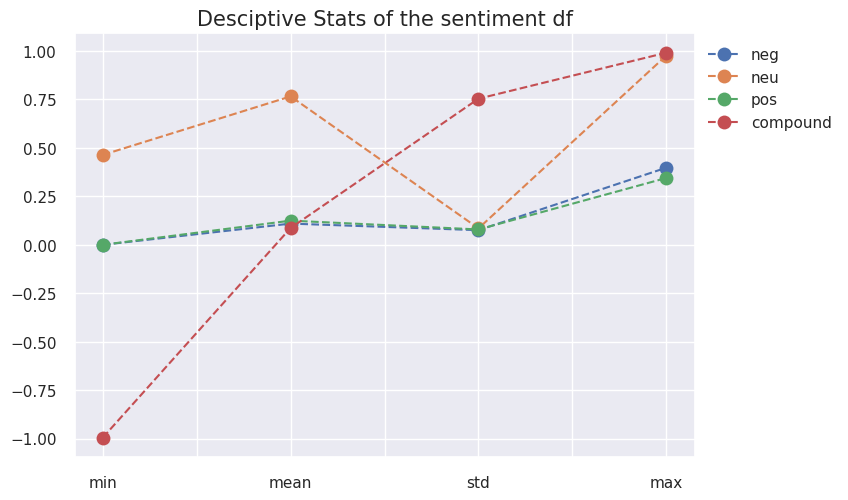

In [ ]:
sentiment_df.describe().loc[["min","mean","std","max"]].plot(
    marker ="o",
    markersize = 10,
    linestyle= "--" )

plt.title("Desciptive Stats of the sentiment df", fontsize= 15)
plt.legend(bbox_to_anchor = (1,1))
plt.show()

In [ ]:
df_movie["sentiment_score"] = sentiment_df["compound"]
df_movie.head(5)

,movie_title,rating,genre,in_theaters_date,movie_info,directors,director_gender,tomatometer_rating,audience_rating,critics_consensus,sentiment_score
0,A Dog's Journey,PG,"Drama, Kids & Family",5/17/19,Bailey (voiced again by Josh Gad) is living th...,Gail Mancuso,female,50,92,A Dog's Journey is as sentimental as one might...,0.9837
1,A Dog's Way Home,PG,Drama,1/11/19,"Separated from her owner, a dog sets off on an...",Charles Martin Smith,male,60,71,A Dog's Way Home may not quite be a family-fri...,0.9237
2,A Tuba to Cuba,NR,"Documentary, Musical & Performing Arts",2/15/19,The leader of New Orleans' famed Preservation ...,"Danny Clinch, T.G. Herrington",male,100,82,NaN,0.9360
3,A Vigilante,R,Drama,3/29/19,"A once abused woman, Sadie (Olivia Wilde), dev...",Sarah Daggar-Nickson,female,92,50,Led by Olivia Wilde's fearless performance and...,-0.0334
4,After,PG-13,"Drama, Romance",4/12/19,Based on Anna Todd's best-selling novel which ...,Jenny Gage,female,17,72,"Tepid and tired, After's fun flourishes are le...",0.9349


5. Sort the sentiment scores to return the top 10 and bottom 10 sentiment scores and their corresponding movie titles

In [ ]:
pd.set_option("display.max_colwidth", None)

In [ ]:
df_movie[["movie_title","movie_info","sentiment_score"]].sort_values(by =["sentiment_score"], ascending = False)[:10]

,movie_title,movie_info,sentiment_score
23,Breakthrough,"BREAKTHROUGH is based on the inspirational true story of one mother's unfaltering love in the face of impossible odds. When Joyce Smith's adopted son John falls through an icy Missouri lake, all hope seems lost. But as John lies lifeless, Joyce refuses to give up. Her steadfast belief inspires those around her to continue to pray for John's recovery, even in the face of every case history and scientific prediction. From producer DeVon Franklin (Miracles from Heaven) and adapted for the screen by Grant Nieporte (Seven Pounds) from Joyce Smith's own book, BREAKTHROUGH is an enthralling reminder that faith and love can create a mountain of hope, and sometimes even a miracle.",0.9915
81,Missing Link,"This April, meet Mr. Link (Galifianakis): 8 feet tall, 630 lbs, and covered in fur, but don't let his appearance fool you... he is funny, sweet, and adorably literal, making him the world's most lovable legend at the heart of Missing Link, the globe-trotting family adventure from LAIKA. Tired of living a solitary life in the Pacific Northwest, Mr. Link recruits fearless explorer Sir Lionel Frost (Jackman) to guide him on a journey to find his long-lost relatives in the fabled valley of Shangri-La. Along with adventurer Adelina Fortnight (Saldana), our fearless trio of explorers encounter more than their fair share of peril as they travel to the far reaches of the world to help their new friend. Through it all, the three learn that sometimes you can find a family in the places you least expect.",0.9909
130,The Laundromat,"When her idyllic vacation takes an unthinkable turn, Ellen Martin (Academy Award winner Meryl Streep) begins investigating a fake insurance policy, only to find herself down a rabbit hole of questionable dealings that can be linked to a Panama City law firm and its vested interest in helping the world's wealthiest citizens amass even larger fortunes. The charming -- and very well-dressed -- founding partners Jürgen Mossack (Academy Award winner Gary Oldman) and Ramón Fonseca (Golden Globe nominee Antonio Banderas) are experts in the seductive ways shell companies and offshore accounts help the rich and powerful prosper. They are about to show us that Ellen's predicament only hints at the tax evasion, bribery and other illicit absurdities that the super wealthy indulge in to support the world's corrupt financial system.",0.9908
48,Five Feet Apart,"Stella Grant (Haley Lu Richardson) is every bit a seventeen-year-old... she's attached to her laptop and loves her best friends. But unlike most teenagers, she spends much of her time living in a hospital as a cystic fibrosis patient. Her life is full of routines, boundaries and self-control -- all of which is put to the test when she meets an impossibly charming fellow CF patient named Will Newman (Cole Sprouse). There's an instant flirtation, though restrictions dictate that they must maintain a safe distance between them. As their connection intensifies, so does the temptation to throw the rules out the window and embrace that attraction. Further complicating matters is Will's potentially dangerous rebellion against his ongoing medical treatment. Stella gradually inspires Will to live life to the fullest, but can she ultimately save the person she loves when even a single touch is off limits?",0.9889
156,UglyDolls,"In the adorably different town of Uglyville, weird is celebrated, strange is special and beauty is embraced as more than simply meets the eye. Here, the free-spirited Moxy (Clarkson) and her UglyDoll friends live every day in a whirlwind of bliss, letting their freak flags fly in a celebration of life and its endless possibilities. In this all-new story, the UglyDolls will go on a journey beyond the comfortable borders of Uglyville. There, they will confront what it means to be different, struggle with their desire to be loved, and ultimately discover that you don't have to be perfect to be amazing because

## 2. Text Classification

1. Clean and normalize the _movie_info_ column using the _maven_text_preprocessing.py_ module
2. Create a Count Vectorizer
* Remove stop words
* Set the minimum document frequency to 10%
3. Create a Naïve Bayes model and a Logistic Regression model to predict which movies are directed by women vs men using the CV
4. Compare their accuracy scores and classification reports
5. Using the better performing model, return the top 5 movies that the model predicts are most likely directed by a women

--------------------------------------------------------------------------------

In [ ]:
mylist = [1,2,3]

In [ ]:
1  in mylist

True

1. Clean and normalize the movie_info column using the maven_text_preprocessing.py module

In [ ]:
# def text_preprocessing(text:str) -> str:
#   import spacy
#   import string

#   nlp = spacy.load("en_core_web_sm")

#   doc = nlp(text)
#   output = [
#       token.lemma_.lower()
#       for token in doc
#       if not token.is_stop  and token.text not in string.punctuation ]


#   return " ".join(output)


In [ ]:
# df_movie["movie_info_clean3"] = df_movie["movie_info"].apply(text_preprocessing)
# df_movie

In [ ]:
#(df_movie["movie_info_clean"] == df_movie["movie_info_clean3"]).sum()

In [ ]:
#df_movie[~ (df_movie["movie_info_clean"] == df_movie["movie_info_clean3"])]

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
def tokenization(text : str):
  doc = nlp(text)
  output = [token.text for token in doc]
  return output

In [ ]:
df_movie["movie_info_clean"] = df_movie["movie_info"].apply(tokenization)

In [ ]:
df_movie.head(1)

,movie_title,rating,genre,in_theaters_date,movie_info,directors,director_gender,tomatometer_rating,audience_rating,critics_consensus,sentiment_score,movie_info_clean
0,A Dog's Journey,PG,"Drama, Kids & Family",5/17/19,"Bailey (voiced again by Josh Gad) is living the good life on the Michigan farm of his ""boy,"" Ethan (Dennis Quaid) and Ethan's wife Hannah (Marg Helgenberger). He even has a new playmate: Ethan and Hannah's baby granddaughter, CJ. The problem is that CJ's mom, Gloria (Betty Gilpin), decides to take CJ away. As Bailey's soul prepares to leave this life for a new one, he makes a promise to Ethan to find CJ and protect her at any cost. Thus begins Bailey's adventure through multiple lives filled with love, friendship and devotion as he, CJ (Kathryn Prescott), and CJ's best friend Trent (Henry Lau) experience joy and heartbreak, music and laughter, and few really good belly rubs.",Gail Mancuso,female,50,92,"A Dog's Journey is as sentimental as one might expect, but even cynical viewers may find their ability to resist shedding a tear stretched to the puppermost limit.",0.9837,"[Bailey, (, voiced, again, by, Josh, Gad, ), is, living, the, good, life, on, the, Michigan, farm, of, his, "", boy, ,, "", Ethan, (, Dennis, Quaid, ), and, Ethan, 's, wife, Hannah, (, Marg, Helgenberger, ), ., He, even, has, a, new, playmate, :, Ethan, and, Hannah, 's, baby, granddaughter, ,, CJ, ., The, problem, is, that, CJ, 's, mom, ,, Gloria, (, Betty, Gilpin, ), ,, decides, to, take, CJ, away, ., As, Bailey, 's, soul, prepares, to, leave, this, life, for, a, new, one, ,, he, makes, a, promise, to, Ethan, to, find, CJ, and, protect, her, ...]"


In [ ]:
def lemmatization(text:str)-> list:
  doc = nlp(text)
  output = [token.lemma_ for token in doc if not token.is_stop]
  return output

In [ ]:
df_movie["movie_info_clean"] = df_movie["movie_info_clean"].apply(lambda X : " ".join(X)).apply(lemmatization)

In [ ]:
df_movie.head(1)

,movie_title,rating,genre,in_theaters_date,movie_info,directors,director_gender,tomatometer_rating,audience_rating,critics_consensus,sentiment_score,movie_info_clean
0,A Dog's Journey,PG,"Drama, Kids & Family",5/17/19,"Bailey (voiced again by Josh Gad) is living the good life on the Michigan farm of his ""boy,"" Ethan (Dennis Quaid) and Ethan's wife Hannah (Marg Helgenberger). He even has a new playmate: Ethan and Hannah's baby granddaughter, CJ. The problem is that CJ's mom, Gloria (Betty Gilpin), decides to take CJ away. As Bailey's soul prepares to leave this life for a new one, he makes a promise to Ethan to find CJ and protect her at any cost. Thus begins Bailey's adventure through multiple lives filled with love, friendship and devotion as he, CJ (Kathryn Prescott), and CJ's best friend Trent (Henry Lau) experience joy and heartbreak, music and laughter, and few really good belly rubs.",Gail Mancuso,female,50,92,"A Dog's Journey is as sentimental as one might expect, but even cynical viewers may find their ability to resist shedding a tear stretched to the puppermost limit.",0.9837,"[Bailey, (, voice, Josh, Gad, ), live, good, life, Michigan, farm, "", boy, ,, "", Ethan, (, Dennis, Quaid, ), Ethan, wife, Hannah, (, Marg, Helgenberger, ), ., new, playmate, :, Ethan, Hannah, baby, granddaughter, ,, CJ, ., problem, CJ, mom, ,, Gloria, (, Betty, Gilpin, ), ,, decide, CJ, away, ., Bailey, soul, prepare, leave, life, new, ,, make, promise, Ethan, find, cj, protect, cost, ., begin, Bailey, adventure, multiple, life, fill, love, ,, friendship, devotion, ,, CJ, (, Kathryn, Prescott, ), ,, CJ, good, friend, Trent, (, Henry, Lau, ), experience, joy, heartbreak, ,, music, laughter, ,, good, ...]"


In [ ]:
# Punctuation finder:
def punctuation_finder(text:str)->list:
  import string
  output = [token.lower() for token in text if token not in string.punctuation]
  return " ".join(output)

In [ ]:
df_movie["movie_info_clean"] = df_movie["movie_info_clean"].apply(punctuation_finder)

In [ ]:
df_movie.head(1)

,movie_title,rating,genre,in_theaters_date,movie_info,directors,director_gender,tomatometer_rating,audience_rating,critics_consensus,sentiment_score,movie_info_clean
0,A Dog's Journey,PG,"Drama, Kids & Family",5/17/19,"Bailey (voiced again by Josh Gad) is living the good life on the Michigan farm of his ""boy,"" Ethan (Dennis Quaid) and Ethan's wife Hannah (Marg Helgenberger). He even has a new playmate: Ethan and Hannah's baby granddaughter, CJ. The problem is that CJ's mom, Gloria (Betty Gilpin), decides to take CJ away. As Bailey's soul prepares to leave this life for a new one, he makes a promise to Ethan to find CJ and protect her at any cost. Thus begins Bailey's adventure through multiple lives filled with love, friendship and devotion as he, CJ (Kathryn Prescott), and CJ's best friend Trent (Henry Lau) experience joy and heartbreak, music and laughter, and few really good belly rubs.",Gail Mancuso,female,50,92,"A Dog's Journey is as sentimental as one might expect, but even cynical viewers may find their ability to resist shedding a tear stretched to the puppermost limit.",0.9837,bailey voice josh gad live good life michigan farm boy ethan dennis quaid ethan wife hannah marg helgenberger new playmate ethan hannah baby granddaughter cj problem cj mom gloria betty gilpin decide cj away bailey soul prepare leave life new make promise ethan find cj protect cost begin bailey adventure multiple life fill love friendship devotion cj kathryn prescott cj good friend trent henry lau experience joy heartbreak music laughter good belly rub


2. Create a Count Vectorizer & TF-IF Vectorizer
* Remove stop words
* Set the minimum document frequency to 10%

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words='english', min_df=0.10)
dtm = cv.fit_transform(df_movie["movie_info_clean"])

In [ ]:
dtm.toarray()

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [1, 0, 0, ..., 1, 0, 0],
       [0, 1, 1, ..., 0, 0, 0]])

In [ ]:
dtm.toarray().shape

(166, 24)

In [ ]:
df_dtm = pd.DataFrame(dtm.toarray(),
                      columns = cv.get_feature_names_out())
df_dtm

,begin,discover,dream,family,film,follow,force,friend,home,leave,...,new,old,set,star,story,turn,woman,world,year,young
0,1,0,0,0,0,0,0,1,0,1,...,2,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,1,0,...,1,0,1,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
162,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
163,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,0,1
164,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,1,0,0


3. Create a Naïve Bayes model and a Logistic Regression model to predict which movies are directed by women vs men using the CV

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
y = df_movie["director_gender"]
y.value_counts()

,count
director_gender,
male,134
female,32


In [ ]:
X_dtm_train, X_dtm_test, y_dtm_train, y_dtm_test = train_test_split(df_dtm,y , test_size=0.20 , random_state=42)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_dtm_train , y_dtm_train)
nb_pred = nb_model.predict(X_dtm_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(df_dtm,y , test_size=0.20 , random_state=42)

In [ ]:
model_lr =LogisticRegression()
model_lr.fit(X_train_lr , y_train_lr)
model_lr_pred = model_lr.predict(X_test_lr)


4. Compare their accuracy scores and classification reports

In [ ]:
print(accuracy_score(y_dtm_test, nb_pred))

0.7647058823529411


In [ ]:
print(classification_report(y_dtm_test, nb_pred))

              precision    recall  f1-score   support

      female       0.00      0.00      0.00         5
        male       0.84      0.90      0.87        29

    accuracy                           0.76        34
   macro avg       0.42      0.45      0.43        34
weighted avg       0.72      0.76      0.74        34



In [ ]:
print(accuracy_score(y_dtm_test, model_lr_pred))

0.7647058823529411


In [ ]:
print(classification_report(y_dtm_test, model_lr_pred))

              precision    recall  f1-score   support

      female       0.20      0.20      0.20         5
        male       0.86      0.86      0.86        29

    accuracy                           0.76        34
   macro avg       0.53      0.53      0.53        34
weighted avg       0.76      0.76      0.76        34



5. Using the better performing model, return the top 5 movies that the model predicts are most likely directed by a women

In [ ]:
df_movie["female_director_prediction"] = model_lr.predict_proba(df_dtm)[:,0]

In [ ]:
df_movie[["movie_title", "female_director_prediction"]].sort_values(by = "female_director_prediction", ascending = False).head(5)

,movie_title,female_director_prediction
55,Greta,0.788841
140,The Secret Life of Pets 2,0.660324
16,Ash Is Purest White,0.654148
76,Mary Magdalene,0.603968
0,A Dog's Journey,0.603593


## 3. Topic Modeling

1. Using the same preprocessed data as the last assignment, create a Tfidf Vectorizer
* Remove stop words
* Start with min_df = 0.05 and max_df=0.2
2. Create an NMF model to find the main topics in the movie descriptions
* Start with n_components=2
3. Tweak the model by updating the Tfidf Vectorizer parameters and number of topics
4. Interpret and name the topics
5. For two of the topics, return the top movies that contain the topic

--------------------------------------------------------------------------

1. Using the same preprocessed data as the last assignment, create a
* Tfidf Vectorizer
* Remove stop words
* Start with min_df = 0.05 and max_df=0.2

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer(stop_words="english", ngram_range = (1,2), min_df = 0.05, max_df = 0.2)
tfidf = tv.fit_transform(df_movie["movie_info_clean"])

df_tfidf = pd.DataFrame(tfidf.toarray(),
                        columns=tv.get_feature_names_out())
df_tfidf

,academy,academy award,action,adventure,american,award,base,battle,begin,black,...,unexpected,war,way,winner,woman,work,write,year,year old,young
0,0.0,0.0,0.0,0.252803,0.0,0.0,0.000000,0.0,0.224410,0.0,...,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.37314,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.368245,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.000000,0.0,0.0,0.295932,0.0,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
162,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
163,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.408592,0.0,0.0,0.0,0.0,0.403327
164,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.429157,0.0,...,0.0,0.0,0.00000,0.0,0.400122,0.0,0.0,0.0,0.0,0.000000


2. Create an NMF model to find the main topics in the movie descriptions
Start with n_components=2

In [ ]:
from sklearn.decomposition import NMF
nmf_model = NMF(n_component = 2 , random_state = 42)
W = nmf_model.fit_transform()